In [1]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict

In [2]:
class BatsmanState(TypedDict):
    runs : int
    balls : int
    fours : int
    sixes : int

    sr : float
    bpb : float
    boundary_percent : float
    summary : str

In [3]:
def calculate_sr(state : BatsmanState) -> BatsmanState:

    runs = state['runs']
    balls = state['balls']

    if balls == 0 :
        sr = 0
    else :     
        sr = (runs/balls) * 100
    state['sr'] = sr

    return {'sr':sr}

In [4]:
def calculate_bpb(state : BatsmanState) -> BatsmanState:
    balls = state['balls']
    fours = state['fours']
    sixes = state['sixes']

    boundary = fours + sixes 
    
    if boundary == 0:
        bpb = 0
    else:
        bpb = balls / boundary
    

    state['bpb'] = bpb 

    return {'bpb':bpb}

In [5]:
def calculate_boundary_percentage(state : BatsmanState) -> BatsmanState:
    runs = state['runs']
    fours = state['fours']
    sixes = state['sixes']

    boundary_runs = fours * 4 + sixes * 6

    if runs == 0:
        bp = 0
    else:
        bp = (boundary_runs / runs) * 100


    state['boundary_percent'] = bp

    return {'boundary_percent':bp}

In [6]:
def summary(state : BatsmanState) -> BatsmanState : 
    summary = f"""
    Strike Rate - {state['sr']}\n
    Balls per boundary - {state['bpb']}\n
    Boundary Percent - {state['boundary_percent']}
    """
    state['summary'] = summary

    return {'summary':summary}

In [7]:
graph =  StateGraph(BatsmanState)

In [8]:
graph.add_node('Strike Rate',calculate_sr)
graph.add_node('Balls per Boundary',calculate_bpb)
graph.add_node('Boundary Percentage',calculate_boundary_percentage)
graph.add_node('Summary',summary)

In [9]:
graph.add_edge(START,'Strike Rate')
graph.add_edge(START,'Balls per Boundary')
graph.add_edge(START,'Boundary Percentage')

graph.add_edge('Strike Rate','Summary')
graph.add_edge('Balls per Boundary','Summary')
graph.add_edge('Boundary Percentage','Summary')

graph.add_edge('Summary',END)

In [10]:
workflow = graph.compile()

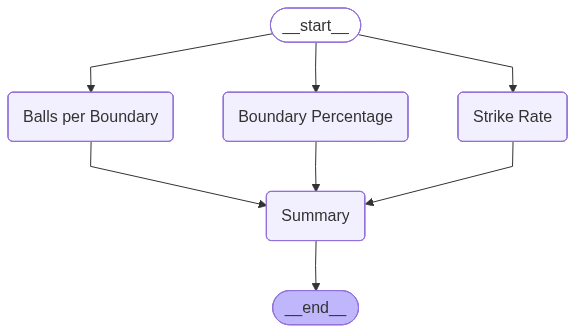

In [11]:
workflow

In [12]:
initial_state = {
    'runs' : 100 , 
    'balls' : 50,
    'fours':6,
    'sixes':4
}

final_state = workflow.invoke(initial_state)

print(final_state)

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4, 'sr': 200.0, 'bpb': 5.0, 'boundary_percent': 48.0, 'summary': '\n    Strike Rate - 200.0\n\n    Balls per boundary - 5.0\n\n    Boundary Percent - 48.0\n    '}
